<a href="https://colab.research.google.com/github/Eng-NadeenShadeed/BinX_AI_ML_Internship/blob/main/Week7/Day%204/Hands_On_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os

os.chdir('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 4')
print("Ready ✓")
print("Files:", os.listdir('.'))

Mounted at /content/drive
Ready ✓
Files: ['Data', 'distilbert_medical_results', 'distilbert_medical_abstracts', '.gradio']


# Week 7 · Day 4 — Hands-On Lab: Attention & Transformers
**BinX Tech — AI & ML Internship**

Medical Abstracts Classification with DistilBERT

## Objective

This lab applies a pretrained Transformer model to a real medical text
classification task using the Medical Abstracts dataset.

**Dataset:** 14,438 medical abstracts — 5 disease categories  
**Model:** DistilBERT — a compressed, faster version of BERT  
**Task:** Multi-class text classification

| Class | Disease Category |
|-------|-----------------|
| 1 | Neoplasms |
| 2 | Digestive system diseases |
| 3 | Nervous system diseases |
| 4 | Cardiovascular diseases |
| 5 | General pathological conditions |

**Why DistilBERT for medical text?**
Medical abstracts are long, technical sentences with complex terminology.
The meaning of a word often depends on distant context — "not malignant"
vs "malignant" — exactly the kind of long-range dependency that Transformers
handle better than RNNs.

**Connection to the cardiac project:**
Class 4 (Cardiovascular diseases) covers the same medical domain as the
cardiac monitoring project. This lab demonstrates how a Transformer
approaches the same domain from a text perspective.

---

## Step 1 — Install & Import Libraries

In [3]:
!pip install transformers datasets torch scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")
print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")

Libraries loaded ✓
PyTorch version : 2.11.0+cu128
GPU available   : True
GPU name        : Tesla T4


---

## Step 2 — Load & Explore the Dataset

In [4]:
# Load data
train_df = pd.read_csv('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 4/Data/medical_abstracts_train.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 4/Data/medical_abstracts_test.csv')

# Class names
class_names = {
    1: "Neoplasms",
    2: "Digestive system diseases",
    3: "Nervous system diseases",
    4: "Cardiovascular diseases",
    5: "General pathological conditions"
}

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print()
print("Columns:", train_df.columns.tolist())
print()
print("Class Distribution — Training Set")
print("=" * 50)
for label, name in class_names.items():
    count = (train_df['condition_label'] == label).sum()
    pct   = count / len(train_df) * 100
    bar   = "█" * int(pct / 2)
    print(f"Class {label} ({name:<35}): {count:>4} ({pct:.1f}%) {bar}")
print()
print(f"Total training samples: {len(train_df):,}")
print(f"Total test samples    : {len(test_df):,}")

Train shape: (11550, 2)
Test shape : (2888, 2)

Columns: ['condition_label', 'medical_abstract']

Class Distribution — Training Set
Class 1 (Neoplasms                          ): 2530 (21.9%) ██████████
Class 2 (Digestive system diseases          ): 1195 (10.3%) █████
Class 3 (Nervous system diseases            ): 1540 (13.3%) ██████
Class 4 (Cardiovascular diseases            ): 2441 (21.1%) ██████████
Class 5 (General pathological conditions    ): 3844 (33.3%) ████████████████

Total training samples: 11,550
Total test samples    : 2,888


---

### Dataset Overview

| Split | Samples |
|-------|---------|
| Training | 11,550 |
| Test | 2,888 |

**Class distribution:**
The dataset is moderately imbalanced — Class 5 (General pathological conditions)
makes up 33.3% while Class 2 (Digestive system diseases) is only 10.3%.
This is less extreme than the ECG dataset (82.8% Normal) — so class weighting
may not be strictly necessary here, but worth monitoring during evaluation.

**Class 4 — Cardiovascular diseases (21.1%):**
This class covers the same medical domain as the cardiac monitoring project.
A Transformer trained on this dataset learns to recognize cardiovascular
terminology and clinical patterns from text — a different modality than
the tabular features used in Sprint 2, but the same clinical domain.

---

## Step 3 — Explore Sample Abstracts

In [5]:
# Show one sample abstract per class
print("Sample Medical Abstracts — One per Class")
print("=" * 70)

for label, name in class_names.items():
    sample = train_df[train_df['condition_label'] == label]['medical_abstract'].iloc[0]
    print(f"\nClass {label} — {name}")
    print("-" * 50)
    print(sample[:300] + "..." if len(sample) > 300 else sample)
    print(f"(Total length: {len(sample)} characters)")

Sample Medical Abstracts — One per Class

Class 1 — Neoplasms
--------------------------------------------------
Neuropeptide Y and neuron-specific enolase levels in benign and malignant pheochromocytomas. Neuron-specific enolase (NSE) is the isoform of enolase, a glycolytic enzyme found in the neuroendocrine system. Neuropeptide Y (NPY) is a peptide recently discovered in the peripheral and central nervous sy...
(Total length: 1207 characters)

Class 2 — Digestive system diseases
--------------------------------------------------
Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two decades, an explosive growth in both the prevalence and types of sexually transmitted diseases has occurred. Up to 55 percent of homosexual men with anorectal complaints have gonorrhea; 8...
(Total length: 1771 characters)

Class 3 — Nervous system diseases
--------------------------------------------------
Does carotid restenosis predict an increa

### Interpretation

The sample abstracts provide a first look at the type of text used in this classification task.

Several observations can be made from these examples:

* **Medical terminology is highly specialized:** The abstracts contain clinical terms such as *pheochromocytomas*, *thrombolysis*, *carotid restenosis*, and *prosthesis*.
* **The abstracts contain substantial context:** Each sample consists of multiple sentences rather than a short keyword or phrase. This means that correctly identifying the disease category may depend on understanding relationships between different parts of the text.
* **Different classes have different clinical themes:** Each category contains abstracts related to a broad medical domain, but the boundaries between some categories may still be challenging because medical concepts can overlap.
* **Text length varies across abstracts:** The examples range from approximately 1,000 to 1,800 characters, suggesting that sequence length will be an important consideration during tokenization.

This observation motivates the next stage of the analysis: measuring the text characteristics of the complete dataset before applying the Transformer.

Understanding the distribution of text lengths will help us make an informed decision about tokenization, padding, and truncation.


---

## Step 4 — Dataset Quality & Text EDA

Before applying tokenization and training the Transformer, we first examine the quality and characteristics of the text data.

This step helps us identify potential data-quality issues and understand the structure of the medical abstracts that DistilBERT will process.

We will investigate:

* Missing values
* Duplicate abstracts
* Text length distribution
* Average and maximum abstract length
* Text length across disease categories

Understanding these characteristics is important because Transformer models process text as sequences of tokens rather than raw strings. Very long abstracts may exceed the model's maximum input length and therefore require truncation during tokenization.


### 4.1 — Checking for Missing Values

Before analyzing the text, we first check whether any samples contain missing values.

Missing values in the medical abstract or target label could affect both preprocessing and model training. Identifying them at this stage allows us to determine whether any cleaning or imputation is required.


In [6]:
# Check for missing values
print("Missing Values")
print("=" * 50)

print(train_df.isnull().sum())
print()
print(test_df.isnull().sum())

Missing Values
condition_label     0
medical_abstract    0
dtype: int64

condition_label     0
medical_abstract    0
dtype: int64


**Interpretation**

The results show **0 missing values** in both the training and test sets.

Both required columns — `condition_label` and `medical_abstract` — are complete. Therefore, no rows need to be removed and no missing-value imputation is required before proceeding to text preprocessing.

This provides a clean starting point for the tokenization and modeling stages.


---

### 4.2 — Checking for Duplicate Abstracts

Duplicate text samples can affect model evaluation and may lead to data leakage.

If the same medical abstract appears multiple times within a dataset, it provides repeated examples of the same text. More importantly, if an identical abstract appears in both the training and test sets, the model may encounter the exact same text during training and evaluation.

In that case, the test set would no longer represent completely unseen data, which could result in overly optimistic evaluation metrics.

Therefore, we check:

1. Duplicate abstracts within the training set.
2. Duplicate abstracts within the test set.
3. Exact text overlap between the training and test sets.


In [7]:
# Check duplicates within each split
train_duplicates = train_df['medical_abstract'].duplicated().sum()
test_duplicates = test_df['medical_abstract'].duplicated().sum()

print(f"Duplicate abstracts in training set: {train_duplicates}")
print(f"Duplicate abstracts in test set    : {test_duplicates}")

# Check overlap between train and test
train_texts = set(train_df['medical_abstract'])
test_texts = set(test_df['medical_abstract'])

overlap = train_texts.intersection(test_texts)

print(f"\nTrain-Test text overlap: {len(overlap)}")

Duplicate abstracts in training set: 2105
Duplicate abstracts in test set    : 118

Train-Test text overlap: 988


**Interpretation**

The duplicate analysis reveals an important data-quality issue.

* The training set contains **2,105 duplicate abstracts**.
* The test set contains **118 duplicate abstracts**.
* Most importantly, **988 unique abstracts appear in both the training and test sets**.

The last result indicates **exact text overlap between the training and test splits**. This creates a potential **data leakage problem**, because the model may see the exact same medical abstract during training and evaluation.

As a result, evaluating the model directly on the original test set could produce overly optimistic performance metrics. The test set would not be completely independent of the training data.

This finding does not mean that the Transformer cannot be trained. Instead, it means that the dataset should be examined further before model training to determine how these duplicate samples are labeled and how the overlap should be handled.

> **Important:** We will investigate the duplicate labels and clean the training data before fine-tuning DistilBERT, while keeping the original test set available for reference.


---

In [8]:
# Check whether duplicated abstracts have consistent labels
duplicate_label_check = (
    train_df.groupby('medical_abstract')['condition_label']
    .nunique()
)

conflicting_train_duplicates = (duplicate_label_check > 1).sum()

print(f"Duplicated abstracts with conflicting labels: {conflicting_train_duplicates}")

Duplicated abstracts with conflicting labels: 1956


**Interpretation**

The duplicate analysis reveals another important characteristic of the dataset.

Among the duplicated abstracts in the training set, **1,956 unique abstracts appear with more than one `condition_label`**.

This means that the same medical text can occur multiple times in the training data while being associated with different disease categories.

This is important for a supervised classification task because the model is expected to learn a consistent relationship between the input text and its target label. If exactly the same text is assigned to different classes, the model receives contradictory training signals.

However, we should not immediately assume that these records are simply incorrect. The dataset may contain repeated abstracts with different annotations or may have been constructed from source records where the same text was associated with different labels.

Therefore, this finding should be documented as a **dataset quality issue** rather than automatically deleting all duplicated samples.

The next step is to inspect the train-test overlap and determine whether the labels assigned to overlapping abstracts are consistent between the two splits.


---

In [9]:
# Compare labels for unique abstracts appearing in both train and test

train_unique_overlap = (
    train_df[train_df['medical_abstract'].isin(overlap)]
    [['medical_abstract', 'condition_label']]
    .drop_duplicates()
)

test_unique_overlap = (
    test_df[test_df['medical_abstract'].isin(overlap)]
    [['medical_abstract', 'condition_label']]
    .drop_duplicates()
)

overlap_comparison = train_unique_overlap.merge(
    test_unique_overlap,
    on='medical_abstract',
    suffixes=('_train', '_test')
)

conflicting_train_test = (
    overlap_comparison['condition_label_train'] !=
    overlap_comparison['condition_label_test']
)

print(f"Unique overlapping abstracts compared: {len(overlap_comparison):,}")
print(f"Train-Test label conflicts: {conflicting_train_test.sum():,}")

Unique overlapping abstracts compared: 1,119
Train-Test label conflicts: 1,119


**Interpretation**

The comparison of unique overlapping abstracts shows a critical issue in the original dataset.

There are **1,119 unique medical abstracts that appear in both the training and test sets**, and all **1,119 have different labels between the two splits**.

This means that the same exact medical abstract is associated with different disease categories depending on whether it appears in the training or test set.

For a supervised text classification problem, this creates a serious data quality issue. The model receives one label for an abstract during training but is evaluated against a different label for the same text in the test set. Therefore, the original train-test split cannot be considered a clean evaluation setup for measuring generalization to unseen medical abstracts.

This finding is also consistent with the earlier observation that many duplicated abstracts have conflicting labels within the training set.

Because of this issue, we should **not use the original train/test split directly as the final evaluation setup**. Instead, we will preserve the original data for traceability and construct a cleaner dataset split in which the same abstract does not appear across training and evaluation sets.

This will allow the final Transformer evaluation to better represent performance on previously unseen medical abstracts.


---

### 4.3 — Analyzing Medical Abstract Length

Transformer models process text as sequences of tokens rather than complete raw documents.

Therefore, understanding the length of the medical abstracts is important before tokenization. If some abstracts are substantially longer than the model's supported input length, they may need to be truncated.

We calculate the number of words in each abstract and examine the average, median, minimum, and maximum lengths.


In [10]:
# Calculate text length in words
train_df['word_count'] = train_df['medical_abstract'].str.split().str.len()
test_df['word_count'] = test_df['medical_abstract'].str.split().str.len()

print("Training Text Statistics")
print("=" * 50)

print(f"Average words : {train_df['word_count'].mean():.1f}")
print(f"Median words  : {train_df['word_count'].median():.1f}")
print(f"Minimum words : {train_df['word_count'].min()}")
print(f"Maximum words : {train_df['word_count'].max()}")

Training Text Statistics
Average words : 179.6
Median words  : 175.0
Minimum words : 24
Maximum words : 596


**Interpretation**

The training abstracts have the following characteristics:

* **Average length:** 179.6 words
* **Median length:** 175 words
* **Minimum length:** 24 words
* **Maximum length:** 596 words

The mean and median are relatively close, indicating that the typical abstract is centered around approximately **175–180 words**.

However, the maximum length of **596 words** shows that some abstracts are considerably longer than the typical sample.

This variation is important for Transformer preprocessing because the model operates on a sequence of tokens rather than words. Since tokenized sequences can contain more tokens than their corresponding word count, some of the longer abstracts may exceed the model's maximum input length.

Therefore, we will use the text-length analysis to guide our choice of `max_length` during tokenization rather than selecting a value arbitrarily.


---

### 4.4 — Distribution of Medical Abstract Lengths

To better understand the variation in abstract length, we visualize the distribution of word counts using a histogram.

The histogram allows us to identify where most abstracts are concentrated and whether the dataset contains a long tail of unusually long texts.


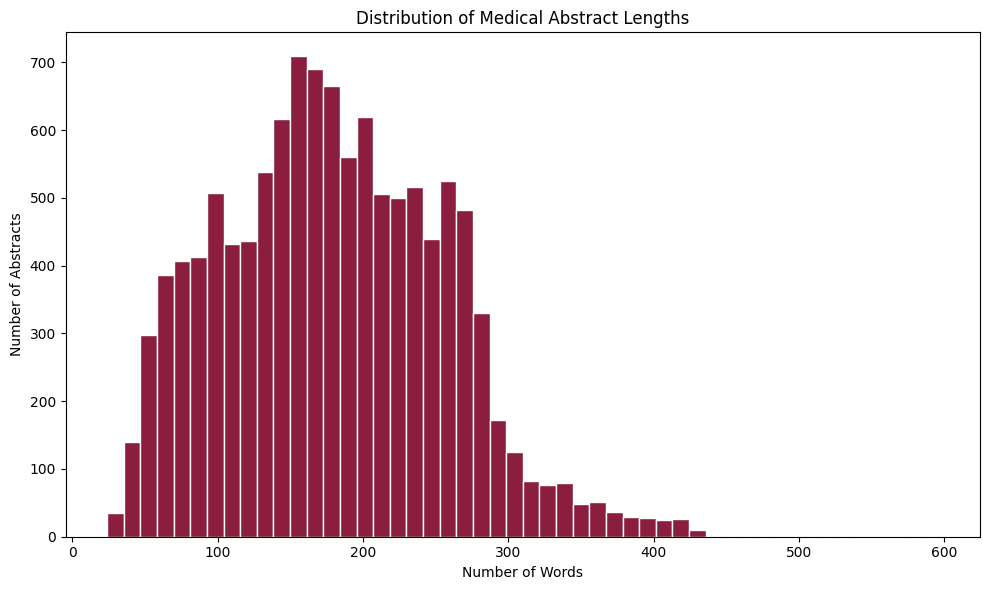

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(train_df['word_count'], bins=50, color="#8B1E3F", edgecolor="white")

plt.xlabel("Number of Words")
plt.ylabel("Number of Abstracts")
plt.title("Distribution of Medical Abstract Lengths")

plt.tight_layout()
plt.show()

**Interpretation**

The histogram shows that most medical abstracts are concentrated within the lower-to-middle range of the observed word counts, while substantially longer abstracts occur less frequently.

The distribution also shows a **right-skewed pattern**, with a longer tail extending toward the maximum observed length of 596 words.

This means that although most abstracts have relatively moderate lengths, a smaller number of abstracts are considerably longer.

This observation is relevant to Transformer preprocessing because the longer texts may require truncation if their tokenized representation exceeds the model's maximum sequence length.

However, word count alone is not sufficient to determine the final `max_length`. In the next preprocessing stage, we will examine the actual **token length distribution produced by the DistilBERT tokenizer** and use that information to make a more informed decision.


---

### 4.5 — Comparing Text Length Across Disease Categories

Text length may vary between medical domains. We therefore compare abstract lengths across the five disease categories using a boxplot.

A boxplot allows us to compare the central tendency, spread, and potential outliers of each category.


<Figure size 1100x600 with 0 Axes>

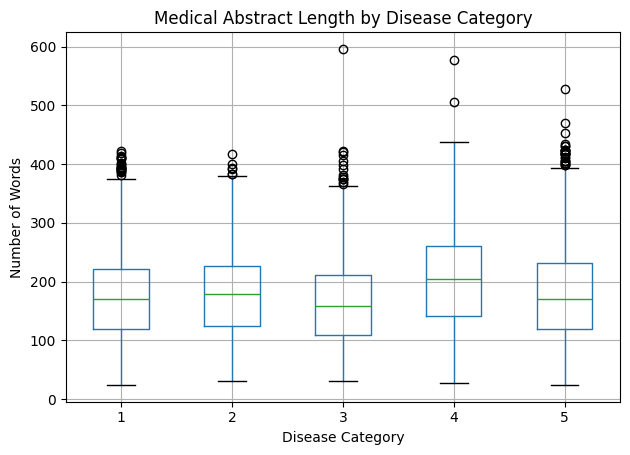

In [12]:
plt.figure(figsize=(11, 6))

train_df.boxplot(
    column='word_count',
    by='condition_label'
)

plt.xlabel("Disease Category")
plt.ylabel("Number of Words")
plt.title("Medical Abstract Length by Disease Category")
plt.suptitle("")

plt.tight_layout()
plt.show()

**Interpretation**

The boxplot shows that the five disease categories have broadly similar distributions of abstract length.

The central portions of the distributions overlap substantially, suggesting that no single disease category is separated from the others purely by text length.

At the same time, all categories contain longer abstracts that appear as outliers. These observations indicate that unusually long abstracts are not restricted to one specific disease category.

Therefore, **abstract length alone is unlikely to be sufficient for distinguishing between the disease categories**. The model will need to learn more informative linguistic and medical patterns from the actual text, including terminology, context, and relationships between words.

This supports the use of a Transformer-based model such as DistilBERT, which can learn contextual representations from the text rather than relying on simple text-length characteristics.


---

### Visualizing Disease Categories

To make the comparison easier to interpret, we repeat the boxplot using the actual disease-category names instead of numerical class labels.

This visualization provides a more readable view of how abstract length is distributed across the five medical categories.


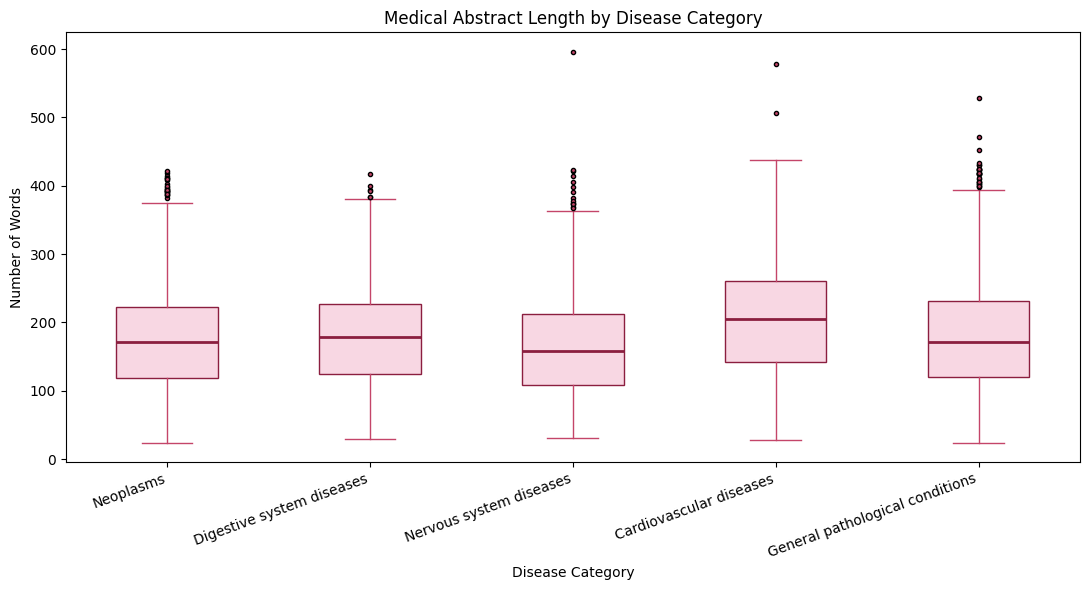

In [13]:
# Prepare text length by class
length_by_class = [
    train_df[train_df['condition_label'] == label]['word_count']
    for label in class_names
]

plt.figure(figsize=(11, 6))

plt.boxplot(length_by_class, labels=[class_names[label] for label in class_names],
            patch_artist=True,
            boxprops=dict(facecolor="#F8D7E3", color="#8B1E3F"),
            medianprops=dict(color="#8B1E3F", linewidth=2),
            whiskerprops=dict(color="#C44569"),
            capprops=dict(color="#C44569"),
            flierprops=dict(markerfacecolor="#C44569", marker="o", markersize=3))

plt.xlabel("Disease Category")
plt.ylabel("Number of Words")
plt.title("Medical Abstract Length by Disease Category")

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**Interpretation**

The named-category visualization confirms the overall pattern observed in the previous boxplot.

The distributions of abstract length overlap considerably across all five categories. Although some categories show slightly different levels of spread and some contain longer outliers, the differences are not large enough to suggest that text length is the primary factor separating the classes.

This is an important observation for the classification task: **the model should learn the medical content and contextual relationships within each abstract rather than relying mainly on document length.**

The presence of long outliers across multiple categories also reinforces the need to examine token lengths during the upcoming tokenization stage.


---

**Text Length Statistics by Disease Category**

To examine whether abstract length varies across the five disease categories, we calculate descriptive statistics for each class, including the number of samples, mean, median, minimum, and maximum word count.

These statistics provide the exact numerical values behind the boxplot and help us compare the typical length and variation of medical abstracts across disease categories.

In [14]:
# Text length statistics by disease category
class_length_stats = (
    train_df.groupby('condition_label')['word_count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .rename(index=class_names)
)

class_length_stats

,count,mean,median,min,max
condition_label,,,,,
Neoplasms,2530,174.173913,171.0,24,422
Digestive system diseases,1195,178.662762,179.0,30,417
Nervous system diseases,1540,163.338312,158.0,31,596
Cardiovascular diseases,2441,200.134781,205.0,28,578
General pathological conditions,3844,177.059573,171.0,24,528


**Interpretation**

The class-level statistics provide a numerical summary of abstract lengths across the five disease categories.

Comparing the mean and median values allows us to determine whether certain categories contain systematically longer or shorter abstracts, while the minimum and maximum values reveal the overall range within each class.

Overall, the statistics should be interpreted together with the boxplot rather than relying on a single measure. The visualizations indicate substantial overlap between the categories, suggesting that text length is not sufficient to distinguish the medical conditions on its own.

These findings further motivate the use of contextual language representations from DistilBERT.


---

## 4.6 — Data Quality Decision and Cleaning Strategy

The dataset analysis revealed an important data-quality issue that must be addressed before model training. Several medical abstracts are repeated within the dataset, and some repeated abstracts are associated with different disease labels. In addition, exact abstracts appear in both the original training and test sets, creating a potential data-leakage problem.

Therefore, the original CSV files will be preserved as the source data, while a separate cleaned dataset will be constructed for modeling. The cleaning process will focus on preventing identical abstracts from appearing across different dataset splits and handling abstracts with inconsistent labels explicitly rather than silently changing their labels.

The original train/test split will not be treated as a reliable leakage-free benchmark after this discovery. Instead, we will construct a clean dataset and create new training, validation, and test splits at the abstract level.


### 4.6.1 — Creating Clean Dataset Copies

Before applying any cleaning operations, create separate copies of the original training and test DataFrames.

This allows us to preserve the original dataset unchanged while performing preprocessing on the copies.


In [15]:
# Preserve the original datasets and combine them into one modeling corpus

modeling_df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

print("Combined modeling dataset created ✓")
print(f"Total rows: {len(modeling_df):,}")
print(f"Unique abstracts: {modeling_df['medical_abstract'].nunique():,}")

Combined modeling dataset created ✓
Total rows: 14,438
Unique abstracts: 11,227


---

### 4.6.2 — Analyzing Conflicting Labels

Before removing repeated abstracts, we need to determine how their labels are distributed. An abstract may appear multiple times with the same label, or it may appear with different labels. These cases should not be treated identically.

We will therefore identify abstracts associated with more than one disease category and inspect their label distributions before deciding how ambiguous records should be handled.


In [16]:
# Analyze how repeated abstracts are distributed across labels

abstract_label_analysis = (
    modeling_df
    .groupby('medical_abstract')
    .agg(
        occurrences=('medical_abstract', 'size'),
        unique_labels=('condition_label', 'nunique')
    )
)

print("Training Abstract Repetition Analysis")
print("=" * 50)

print(f"Unique abstracts              : {len(abstract_label_analysis):,}")
print(
    f"Abstracts appearing multiple times: "
    f"{(abstract_label_analysis['occurrences'] > 1).sum():,}"
)
print(
    f"Abstracts with conflicting labels : "
    f"{(abstract_label_analysis['unique_labels'] > 1).sum():,}"
)
print(
    f"Maximum occurrences of one abstract: "
    f"{abstract_label_analysis['occurrences'].max():,}"
)

Training Abstract Repetition Analysis
Unique abstracts              : 11,227
Abstracts appearing multiple times: 2,929
Abstracts with conflicting labels : 2,929
Maximum occurrences of one abstract: 4


In [17]:
# Analyze label distribution for abstracts with conflicting labels

label_distribution = (
    modeling_df
    .groupby('medical_abstract')['condition_label']
    .agg(
        occurrences='size',
        unique_labels='nunique',
        label_counts=lambda x: x.value_counts().to_dict()
    )
)

conflicting_abstracts = label_distribution[
    label_distribution['unique_labels'] > 1
]

print("Conflicting Abstract Analysis")
print("=" * 60)
print(f"Conflicting abstracts: {len(conflicting_abstracts):,}")

print("\nNumber of unique labels per conflicting abstract:")
print(
    conflicting_abstracts['unique_labels']
    .value_counts()
    .sort_index()
)

print("\nExamples:")
display(conflicting_abstracts.head(10))

Conflicting Abstract Analysis
Conflicting abstracts: 2,929

Number of unique labels per conflicting abstract:
unique_labels
2    2653
3     270
4       6
Name: count, dtype: int64

Examples:


,occurrences,unique_labels,label_counts
medical_abstract,,,
"'Locked-in syndrome' for 27 years following a viral illness: clinical and pathologic findings. We describe a man who, after a presumed encephalitic illness, was ""locked-in"" for 27 years. His CT and autopsy findings showed atrophy of the brainstem and a cystic lesion at the base of the pons. He survived longer than most other patients in a similar state.",3,3,"{3: 1, 5: 1, 1: 1}"
"(A)typical symptoms during single needle dialysis. In 5 elderly patients, an abnormally high occurrence of some symptoms was noted during dialysis. All patients were dialyzed with biocompatible membranes, bicarbonate dialysate, and a blood flow of 250 to 300 ml/min by a single needle system, on a fistula 14 Gauge catheter-needle. These symptoms were: 1) ""angina,"" resistant to O2 and nitrates, with biochemical stigmata of infarction, but without electrocardiogram (ECG) localization; 2) intractable persistent hypotension, not hypovolemic, lasting 1 or 2 days; 3) esophagal spasms, with inability to swallow solid food. Because we knew that these symptoms were compatible with hemolysis (biochemically proven by the increase in serum LDH during dialysis and by a fall in haptoglobin) due to red cell fragmentation (RCF), we switched these patients from fistula dialysis (A) to central catheter dialysis (B), with the same apperture, blood flow, etc. The total number of sessions of A versus B were 512 and 891; the mean LDH ratios (serum LDH postdialysis divided by predialysis) were 1.8 and 1.0 (= no RCF); angina events were 132 (26%) for A, and 25 (3%) for B; persistent hypotension was seen 37 (7%) times in A and 5 (0.6%) times in B; esophagal spasms were noted 65 (13%) times for A, and 0 times for B. This clinical improvement was so overwhelming that 3 patients refused to be dialyzed again using their well functioning fistulae. This study also proved the need for a better designed and manufactured peripheral dialysis catheter-needle.",3,3,"{5: 1, 2: 1, 4: 1}"
7th nerve palsy after extradural blood patch. We describe a patient who developed a 7th cranial nerve palsy following an extradural blood patch; full recovery followed. The likely aetiology is discussed.,2,2,"{3: 1, 5: 1}"
"99TCm-HMPAO SPECT studies in traumatic intracerebral haematoma. Traumatic intracerebral haematomas are a common neurosurgical emergency. Their management, particularly the role of surgical removal, is controversial. Deterioration often occurs late, and is unpredictable. Eight patients with traumatic intracerebral haematomas were admitted to the neurosurgical unit to monitor their clinical state. All were studied within 48 hours of admission with single photon emission computerised tomography (SPECT), using the recently introduced radionuclide 99Technetiumm-Hexamethyl propylene amine oxime (99Tcm-HMPAO). At the time of the SPECT study, all the patients had been clinically stable. Three patients remained so; in the other five, the conscious level deteriorated, necessitating craniotomy and evacuation of the haematoma. In all the patients, the SPECT studies demonstrated perfusion defects that corresponded to the location of the haematoma, as demonstrated by computerised tomography (CT). However, in the five patients who subsequently deteriorated, the perfusion defects seen on the SPECT scan appeared larger than the haematoma, as seen on the CT scan. In addition, there was widespread poor retention of 99Tcm-HMPAO in the ipsilateral hemisphere. These differences were quantifiable. Interestingly, these differences were present at a time when the patients were clinically stable, before their deterioration. It is concluded that SPECT studies with 99Tcm-HMPAO are of possible use as predictors of late deterioration in the management of traumatic intracerebral haematomas.",2,2,"{5: 1, 3: 1}"
"A 5.3-kb deletion including exon XIII of the protein S alpha gene occurs in two protein S-deficient families. Genomic DNA samples from 12 protein

In [18]:
# Inspect how conflicting labels are distributed

conflict_label_pairs = (
    modeling_df[
        modeling_df['medical_abstract'].isin(conflicting_abstracts.index)
    ]
    .groupby('medical_abstract')['condition_label']
    .apply(lambda x: sorted(x.unique()))
)

print("Examples of conflicting label combinations:")
print("=" * 60)

print(
    conflict_label_pairs
    .value_counts()
    .head(15)
)

Examples of conflicting label combinations:
condition_label
[4, 5]       738
[1, 5]       486
[2, 5]       475
[3, 5]       446
[1, 3]       139
[1, 2]       134
[3, 4]       114
[3, 4, 5]     72
[1, 4]        67
[1, 2, 5]     65
[1, 3, 5]     41
[2, 4, 5]     33
[2, 4]        29
[2, 3, 5]     26
[2, 3]        25
Name: count, dtype: int64


In [19]:
# Remove abstracts with conflicting labels
# Keep only abstracts that are associated with exactly one label

single_label_abstracts = (
    label_distribution[label_distribution['unique_labels'] == 1]
    .index
)

clean_modeling_df = modeling_df[
    modeling_df['medical_abstract'].isin(single_label_abstracts)
].copy()

# Keep one row per abstract
clean_modeling_df = (
    clean_modeling_df
    .drop_duplicates(subset=['medical_abstract'])
    .reset_index(drop=True)
)

print("Clean modeling dataset created ✓")
print("=" * 60)
print(f"Original rows          : {len(modeling_df):,}")
print(f"Rows after cleaning    : {len(clean_modeling_df):,}")
print(f"Unique abstracts       : {clean_modeling_df['medical_abstract'].nunique():,}")
print(f"Rows removed           : {len(modeling_df) - len(clean_modeling_df):,}")

Clean modeling dataset created ✓
Original rows          : 14,438
Rows after cleaning    : 8,298
Unique abstracts       : 8,298
Rows removed           : 6,140


---

### 4.6.3 — Data Quality Summary

The exploratory analysis identified three important characteristics of the dataset:

* Repeated medical abstracts occur within the source data.
* Some repeated abstracts are associated with multiple disease labels.
* Exact abstracts occur across the original training and test sets, meaning that the original split cannot be considered fully leakage-free.

These findings do not prevent us from using the dataset, but they require a more careful preprocessing strategy. The original CSV files will remain unchanged for reference, while a separate modeling dataset will be constructed for the experiments.

Before tokenization and model training, we will resolve the duplicate and conflicting-label cases and create new leakage-free training, validation, and test splits at the abstract level.


---

### 4.6.4 — Creating Leakage-Free Train, Validation, and Test Splits

After removing abstracts with conflicting labels, the cleaned dataset contains one unique label for each abstract. We can now create new training, validation, and test sets from the cleaned corpus.

The split will be performed at the abstract level using stratified sampling so that the class distribution remains approximately consistent across all three subsets. This replaces the original train/test split, which was found to contain overlapping abstracts.

The original CSV files remain unchanged and are preserved as the source data.


In [20]:
from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
train_clean, temp_clean = train_test_split(
    clean_modeling_df,
    test_size=0.30,
    stratify=clean_modeling_df['condition_label'],
    random_state=42
)

# Second split: split the 30% temporary set equally
# Result: 70% train, 15% validation, 15% test
validation_clean, test_clean = train_test_split(
    temp_clean,
    test_size=0.50,
    stratify=temp_clean['condition_label'],
    random_state=42
)

# Reset indices
train_clean = train_clean.reset_index(drop=True)
validation_clean = validation_clean.reset_index(drop=True)
test_clean = test_clean.reset_index(drop=True)

print("Leakage-free dataset split created ✓")
print("=" * 60)
print(f"Training set   : {len(train_clean):,}")
print(f"Validation set : {len(validation_clean):,}")
print(f"Test set       : {len(test_clean):,}")
print(f"Total          : {len(train_clean) + len(validation_clean) + len(test_clean):,}")

Leakage-free dataset split created ✓
Training set   : 5,808
Validation set : 1,245
Test set       : 1,245
Total          : 8,298


In [21]:
# Verify that no abstract appears in more than one split

train_texts = set(train_clean['medical_abstract'])
validation_texts = set(validation_clean['medical_abstract'])
test_texts = set(test_clean['medical_abstract'])

train_val_overlap = train_texts.intersection(validation_texts)
train_test_overlap = train_texts.intersection(test_texts)
val_test_overlap = validation_texts.intersection(test_texts)

print("Leakage Verification")
print("=" * 60)
print(f"Train ↔ Validation overlap : {len(train_val_overlap)}")
print(f"Train ↔ Test overlap       : {len(train_test_overlap)}")
print(f"Validation ↔ Test overlap  : {len(val_test_overlap)}")

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\n✓ No abstract appears in more than one split.")
print("✓ Dataset is leakage-free at the abstract level.")

Leakage Verification
Train ↔ Validation overlap : 0
Train ↔ Test overlap       : 0
Validation ↔ Test overlap  : 0

✓ No abstract appears in more than one split.
✓ Dataset is leakage-free at the abstract level.


---

## Step 5 — Tokenization with DistilBERT

A Transformer cannot process raw text directly. Before feeding medical abstracts into DistilBERT, the text must be converted into a numerical representation that the model can understand.

This process is called **tokenization**.

The tokenizer performs several important operations:

* Splits text into tokens that are understood by the pretrained model.
* Converts tokens into numerical **input IDs**.
* Adds special tokens required by DistilBERT.
* Creates an **attention mask** to distinguish real tokens from padding tokens.
* Applies truncation and padding when required.

We will use the tokenizer associated with **DistilBERT**, ensuring that the preprocessing matches the pretrained model's vocabulary and expected input format.


In [22]:
from transformers import DistilBertTokenizer

# Load the tokenizer associated with DistilBERT
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer loaded ✓")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded ✓
Vocabulary size: 30,522


---

### 5.2 — Tokenizing a Medical Abstract

To understand what the tokenizer produces, we will tokenize one medical abstract from the dataset.

Instead of treating the abstract as a single string, the tokenizer converts it into a sequence of tokens and their corresponding numerical IDs.

This demonstrates the first step in transforming natural language into the numerical input required by a Transformer.


In [23]:
# Select one medical abstract
sample_text = train_df['medical_abstract'].iloc[0]

# Tokenize the sample
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Original text:")
print(sample_text[:500] + "...")

print("\nFirst 30 tokens:")
print(tokens[:30])

print("\nFirst 30 token IDs:")
print(token_ids[:30])

print(f"\nTotal tokens: {len(tokens)}")

Original text:
Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were isolated and maintained in culture for sufficient periods of time so that their biologic activity could be studied as well as the effect of different agents added to the cells in vivo or in vitro. The b...

First 30 tokens:
['tissue', 'changes', 'around', 'loose', 'pro', '##st', '##hes', '##es', '.', 'a', 'canine', 'model', 'to', 'investigate', 'the', 'effects', 'of', 'an', 'anti', '##in', '##fl', '##am', '##mat', '##ory', 'agent', '.', 'the', 'as', '##ept', '##ically']

First 30 token IDs:
[8153, 3431, 2105, 6065, 4013, 3367, 15689, 2229, 1012, 1037, 28735, 2944, 2000, 8556, 1996, 3896, 1997, 2019, 3424, 2378, 10258, 3286, 18900, 10253, 4005, 1012, 1996, 2004, 23606, 15004]

To

**Interpretation**

The tokenizer converts the raw medical abstract into a sequence of smaller units called **tokens**.

Each token is mapped to a numerical ID from DistilBERT's vocabulary. These IDs are the values that will ultimately be provided to the neural network.

An important observation is that a token is not always equivalent to a complete word. DistilBERT uses **subword tokenization**, which allows the model to represent common words as complete tokens while splitting less common or specialized words into smaller pieces.

This is particularly useful for medical text because medical terminology often contains long or specialized words that may not appear frequently in the vocabulary.

At this stage, we have converted the text into tokens and token IDs. The next step is to examine the complete encoded representation, including the special tokens and attention mask used by DistilBERT.


---

### 5.3 — Special Tokens and Attention Mask

Tokenization does not only split the text into subword tokens. Before the text is passed to DistilBERT, the tokenizer also prepares the input according to the model's expected format.

Two important components are:

* **Input IDs:** numerical IDs representing the tokens.
* **Attention Mask:** indicates which positions contain real tokens and which positions contain padding.

The tokenizer can also add special tokens required by the model. These tokens provide structural information about the input sequence.

We will encode one medical abstract and inspect these components directly.


In [24]:
# Encode the sample abstract for DistilBERT

encoded_sample = tokenizer(
    sample_text,
    add_special_tokens=True
)

print("Input IDs:")
print(encoded_sample["input_ids"][:30])

print("\nAttention Mask:")
print(encoded_sample["attention_mask"][:30])

print("\nNumber of input IDs:", len(encoded_sample["input_ids"]))
print("Number of attention-mask values:", len(encoded_sample["attention_mask"]))

Input IDs:
[101, 8153, 3431, 2105, 6065, 4013, 3367, 15689, 2229, 1012, 1037, 28735, 2944, 2000, 8556, 1996, 3896, 1997, 2019, 3424, 2378, 10258, 3286, 18900, 10253, 4005, 1012, 1996, 2004, 23606]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Number of input IDs: 212
Number of attention-mask values: 212


In [25]:
# Display the special tokens used by the tokenizer

special_tokens = tokenizer.special_tokens_map

print("Special tokens:")
for token_type, token in special_tokens.items():
    print(f"{token_type:20s}: {token}")

print("\nEncoded sequence tokens:")
print(tokenizer.convert_ids_to_tokens(encoded_sample["input_ids"][:20]))

Special tokens:
unk_token           : [UNK]
sep_token           : [SEP]
pad_token           : [PAD]
cls_token           : [CLS]
mask_token          : [MASK]

Encoded sequence tokens:
['[CLS]', 'tissue', 'changes', 'around', 'loose', 'pro', '##st', '##hes', '##es', '.', 'a', 'canine', 'model', 'to', 'investigate', 'the', 'effects', 'of', 'an', 'anti']


**Interpretation**

The encoded representation contains the numerical information required by DistilBERT.

The **input IDs** represent the tokenized medical abstract using the model's vocabulary. The **attention mask** indicates which positions correspond to actual input tokens.

The tokenizer may also add model-specific special tokens to provide structure to the sequence. These tokens are part of the model's expected input format and are handled automatically by the tokenizer.

An important point is that the number of words in an abstract is not necessarily equal to the number of Transformer tokens. Because DistilBERT uses subword tokenization, a single medical word can be divided into several tokens.

Therefore, the maximum sequence length should not be selected using the word-count analysis alone. We should measure the actual token lengths produced by the DistilBERT tokenizer before deciding on a suitable `max_length`.


---

### 5.4 — Token Length Distribution

The number of words in an abstract does not directly represent the number of tokens processed by DistilBERT.

Because the tokenizer uses subword tokenization, some words may be represented by multiple tokens. Therefore, we need to analyze the actual token lengths produced by the DistilBERT tokenizer across the training dataset.

This analysis will help us choose an appropriate maximum sequence length (`max_length`) for the Transformer.

A suitable `max_length` should be large enough to preserve most of the information in the abstracts while avoiding unnecessary computational cost from processing excessively long sequences.

We will first calculate the token length of every training abstract and then visualize its distribution.


In [26]:
# Analyze token lengths on the final clean training set

token_lengths = [
    len(tokenizer.tokenize(text))
    for text in train_clean['medical_abstract']
]

token_lengths = np.array(token_lengths)

print("Token Length Statistics")
print("=" * 50)
print(f"Number of abstracts : {len(token_lengths):,}")
print(f"Average             : {token_lengths.mean():.1f}")
print(f"Median              : {np.median(token_lengths):.0f}")
print(f"Minimum             : {token_lengths.min()}")
print(f"Maximum             : {token_lengths.max()}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (609 > 512). Running this sequence through the model will result in indexing errors


Token Length Statistics
Number of abstracts : 5,808
Average             : 277.9
Median              : 270
Minimum             : 38
Maximum             : 834


---

#### 5.4.1 — Visualizing Token Length Distribution

The token length statistics show that the medical abstracts vary considerably in size.

The average abstract contains approximately **277.7 tokens**, while the median is **268 tokens**. However, some abstracts are considerably longer, with the maximum reaching **834 tokens**.

Since DistilBERT supports sequences up to **512 tokens**, abstracts longer than this limit cannot be passed to the model without truncation.

To make an informed decision about the maximum sequence length, we will visualize the token-length distribution and calculate several percentiles. This allows us to estimate how many abstracts can be processed without truncation at different sequence lengths.

Rather than choosing a maximum length arbitrarily, we will use the actual distribution of our medical abstracts to guide the decision.


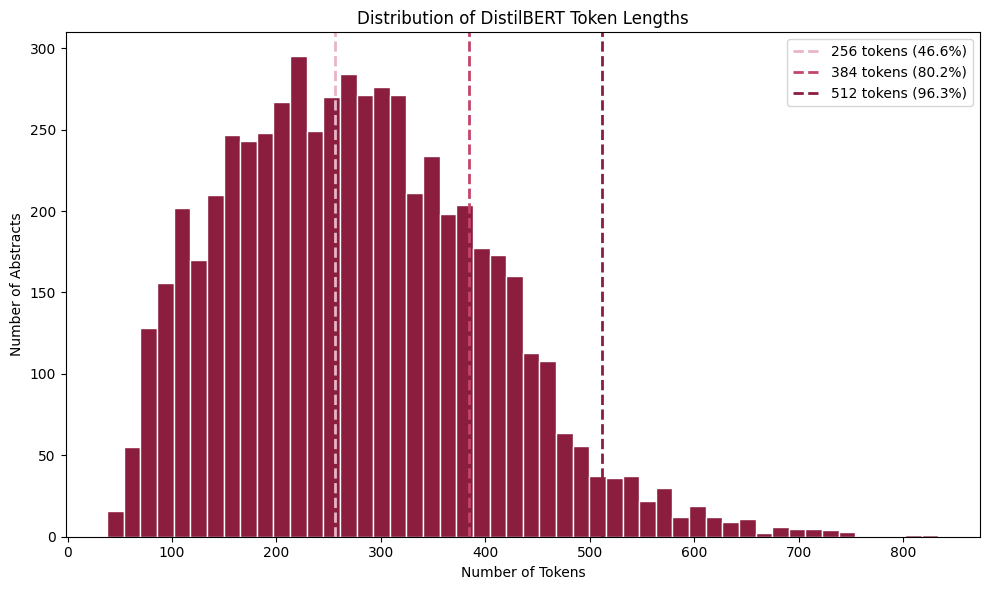

In [27]:
# Visualize the distribution of token lengths

plt.figure(figsize=(10, 6))

plt.hist(token_lengths, bins=50)

plt.xlabel("Number of Tokens")
plt.ylabel("Number of Abstracts")
plt.title("Distribution of DistilBERT Token Lengths")

plt.hist(token_lengths, bins=50, color="#8B1E3F", edgecolor="white")
plt.axvline(256, color="#E8B4C8", linestyle='--', linewidth=2, label='256 tokens (46.6%)')
plt.axvline(384, color="#C44569", linestyle='--', linewidth=2, label='384 tokens (80.2%)')
plt.axvline(512, color="#8B1E3F", linestyle='--', linewidth=2, label='512 tokens (96.3%)')

plt.legend()
plt.tight_layout()
plt.show()

---

#### 5.4.2 — Comparing Candidate Maximum Sequence Lengths

To select an appropriate `max_length`, we compare several candidate sequence lengths and calculate the percentage of abstracts that fit within each limit without truncation.

This provides an objective basis for choosing the sequence length instead of relying only on visual inspection of the histogram.

The candidate values are **256, 384, and 512 tokens**. The last value represents the maximum sequence length supported by DistilBERT, while the smaller values reduce computational and memory requirements.


In [28]:
# Compare coverage at different maximum sequence lengths
# DistilBERT uses 2 special tokens: [CLS] and [SEP]

candidate_lengths = [256, 384, 512]

print("Maximum Sequence Length Comparison")
print("=" * 60)

for max_length in candidate_lengths:

    usable_tokens = max_length - 2

    coverage = (token_lengths <= usable_tokens).mean() * 100
    truncated = (token_lengths > usable_tokens).mean() * 100

    print(
        f"max_length = {max_length:>3} | "
        f"Complete: {coverage:>6.2f}% | "
        f"Truncated: {truncated:>6.2f}%"
    )

Maximum Sequence Length Comparison
max_length = 256 | Complete:  45.82% | Truncated:  54.18%
max_length = 384 | Complete:  79.72% | Truncated:  20.28%
max_length = 512 | Complete:  96.11% | Truncated:   3.89%


---

### 5.4.3 — Selecting the Maximum Sequence Length

The comparison shows a clear trade-off between sequence coverage and computational efficiency.

With a maximum sequence length of 256 tokens, only 45.82% of the training abstracts can be represented without truncation, meaning that more than half of the abstracts would lose part of their content.

Increasing the limit to 384 tokens improves coverage to 79.72%, but 20.28% of the abstracts would still be truncated.

At 512 tokens, 96.11% of the training abstracts fit within the selected sequence length, while only 3.89% require truncation.

Therefore, we select `MAX_LENGTH = 512`. This choice prioritizes preserving contextual information in the medical abstracts while remaining within DistilBERT's supported maximum sequence length. Abstracts longer than the limit will be truncated during tokenization.


In [29]:
MAX_LENGTH = 512

usable_tokens = MAX_LENGTH - 2

coverage = (token_lengths <= usable_tokens).mean() * 100
truncated = (token_lengths > usable_tokens).mean() * 100

print(f"Selected max_length: {MAX_LENGTH}")
print(f"Maximum content tokens: {usable_tokens}")
print(f"Coverage: {coverage:.2f}%")
print(f"Truncated: {truncated:.2f}%")

Selected max_length: 512
Maximum content tokens: 510
Coverage: 96.11%
Truncated: 3.89%


---

### 5.5 — Preparing the Clean Dataset for Tokenization

Now that the maximum sequence length has been selected, we can prepare the cleaned training, validation, and test sets for DistilBERT.

The dataset was previously cleaned by removing abstracts associated with conflicting labels and then creating new leakage-free splits at the abstract level.

During this step:

* The original disease labels are converted from `1–5` to `0–4`, which is the format expected by the classification model.
* The training, validation, and test sets are converted from pandas DataFrames into Hugging Face `Dataset` objects.
* The three sets remain separate so that the validation set can be used during training and the test set can be reserved for final evaluation.


In [30]:
from datasets import Dataset

# Convert labels from 1–5 to 0–4
label_map = {
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    5: 4
}

# Create copies so the original split DataFrames remain unchanged
train_model_df = train_clean.copy()
validation_model_df = validation_clean.copy()
test_model_df = test_clean.copy()

# Map disease labels to 0–4
train_model_df['label'] = train_model_df['condition_label'].map(label_map)
validation_model_df['label'] = validation_model_df['condition_label'].map(label_map)
test_model_df['label'] = test_model_df['condition_label'].map(label_map)

# Convert pandas DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(
    train_model_df[['medical_abstract', 'label']],
    preserve_index=False
)

validation_dataset = Dataset.from_pandas(
    validation_model_df[['medical_abstract', 'label']],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_model_df[['medical_abstract', 'label']],
    preserve_index=False
)

print("Datasets created ✓")
print("=" * 50)
print(f"Training samples   : {len(train_dataset):,}")
print(f"Validation samples : {len(validation_dataset):,}")
print(f"Test samples       : {len(test_dataset):,}")
print(f"Number of labels   : {len(label_map)}")

Datasets created ✓
Training samples   : 5,808
Validation samples : 1,245
Test samples       : 1,245
Number of labels   : 5


---

### 5.6 — Applying the DistilBERT Tokenizer

We now apply the DistilBERT tokenizer to the training, validation, and test datasets.

Each medical abstract will be converted into:

* `input_ids` — numerical IDs representing the tokens.
* `attention_mask` — indicates which positions contain real tokens rather than padding.
* `label` — the corresponding disease category.

Sequences longer than `MAX_LENGTH` will be truncated. Padding will be handled dynamically later during training, which avoids unnecessary padding and reduces computational overhead.


In [31]:
def tokenize_function(examples):
    return tokenizer(
        examples["medical_abstract"],
        truncation=True,
        max_length=MAX_LENGTH
    )

# Tokenize the training, validation, and test datasets
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_validation = validation_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed ✓")
print("=" * 50)
print(f"Training samples   : {len(tokenized_train):,}")
print(f"Validation samples : {len(tokenized_validation):,}")
print(f"Test samples       : {len(tokenized_test):,}")

Map:   0%|          | 0/5808 [00:00<?, ? examples/s]

Map:   0%|          | 0/1245 [00:00<?, ? examples/s]

Map:   0%|          | 0/1245 [00:00<?, ? examples/s]

Tokenization completed ✓
Training samples   : 5,808
Validation samples : 1,245
Test samples       : 1,245


---

#### 5.7 — Inspecting the Tokenized Dataset

Before training the model, we inspect one tokenized example to verify that the abstract has been correctly converted into the inputs required by DistilBERT.

We will check:

* The original label.
* The generated `input_ids`.
* The corresponding `attention_mask`.
* The number of tokens produced after tokenization.

This inspection helps confirm that the dataset is correctly prepared before it is passed to the Transformer model.


In [32]:
# Inspect the first tokenized training example

sample = tokenized_train[0]

print("Available fields:")
print(sample.keys())

print("\nLabel:")
print(sample["label"])

print("\nNumber of input IDs:")
print(len(sample["input_ids"]))

print("\nFirst 20 input IDs:")
print(sample["input_ids"][:20])

print("\nFirst 20 attention-mask values:")
print(sample["attention_mask"][:20])

Available fields:
dict_keys(['medical_abstract', 'label', 'input_ids', 'attention_mask'])

Label:
0

Number of input IDs:
386

First 20 input IDs:
[101, 5390, 2891, 12514, 7301, 1998, 9353, 23320, 2594, 11297, 3370, 2004, 11707, 20621, 2015, 1999, 1996, 3949, 1997, 9376]

First 20 attention-mask values:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


---

### 5.8 — Dynamic Padding

Transformer models require sequences in the same batch to have compatible lengths. Instead of padding every abstract to the global maximum length of 512 tokens, we use dynamic padding.

With dynamic padding, each batch is padded only to the length of its longest sequence. This reduces unnecessary computation and memory usage while preserving the original tokenized content.

The `DataCollatorWithPadding` will handle padding automatically during training and evaluation.


In [33]:
from transformers import DataCollatorWithPadding

# Create a dynamic padding collator
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Dynamic padding collator created ✓")

Dynamic padding collator created ✓


---

### 5.9 — Loading the Pre-trained DistilBERT Model

DistilBERT is a smaller and faster version of BERT that retains the main Transformer-based architecture while reducing computational cost.

For this project, we load `distilbert-base-uncased` with a sequence-classification head configured for five disease categories.

The base DistilBERT weights are pre-trained on large-scale text before being adapted to our medical abstract classification task. The classification head is newly initialized and will be learned during fine-tuning.


In [34]:
from transformers import DistilBertForSequenceClassification

# Load pre-trained DistilBERT with a classification head for 5 classes
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5,
    id2label={
        0: "Neoplasms",
        1: "Digestive system diseases",
        2: "Nervous system diseases",
        3: "Cardiovascular diseases",
        4: "General pathological conditions"
    },
    label2id={
        "Neoplasms": 0,
        "Digestive system diseases": 1,
        "Nervous system diseases": 2,
        "Cardiovascular diseases": 3,
        "General pathological conditions": 4
    }
)

print("DistilBERT model loaded ✓")
print(f"Number of labels: {model.num_labels}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded ✓
Number of labels: 5


---

### 5.10 — Training Configuration

Before fine-tuning, we define the training configuration for DistilBERT.

The model will be trained on the cleaned training set and evaluated on the validation set during training. The test set will remain untouched until the final evaluation.

We use a small learning rate because the Transformer is already pre-trained, while early stopping helps prevent unnecessary training once validation performance stops improving.


In [35]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_medical_abstracts",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none"
)

print("Training configuration created ✓")
print("=" * 50)
print(f"Learning rate        : {training_args.learning_rate}")
print(f"Train batch size     : {training_args.per_device_train_batch_size}")
print(f"Evaluation batch size: {training_args.per_device_eval_batch_size}")
print(f"Maximum epochs       : {training_args.num_train_epochs}")
print(f"Weight decay         : {training_args.weight_decay}")
print(f"Best model metric    : {training_args.metric_for_best_model}")

Training configuration created ✓
Learning rate        : 2e-05
Train batch size     : 16
Evaluation batch size: 16
Maximum epochs       : 5
Weight decay         : 0.01
Best model metric    : f1


---

### 5.11 — Evaluation Metrics

To evaluate the classifier during fine-tuning, we track accuracy and macro-averaged F1-score.

Accuracy measures the overall proportion of correctly classified abstracts. Macro F1 calculates the F1-score independently for each disease category and then averages the five class scores equally. This is useful for our dataset because the class distribution is not perfectly balanced.

The same metrics will be used for the final evaluation on the held-out test set.


In [36]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "f1": macro_f1
    }

print("Evaluation metrics function created ✓")

Evaluation metrics function created ✓


---

### 5.12 — Trainer Setup

The Hugging Face `Trainer` provides the training loop for fine-tuning DistilBERT.

It combines the pre-trained model, training configuration, tokenized training and validation datasets, dynamic padding, and evaluation metrics into a single training workflow.

The test dataset is intentionally excluded from the training process and will only be used for the final performance evaluation.


In [37]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("Trainer initialized ✓")
print("=" * 50)
print(f"Training samples   : {len(tokenized_train):,}")
print(f"Validation samples : {len(tokenized_validation):,}")
print(f"Test samples       : {len(tokenized_test):,}")
print("Test set used during training: No ✓")
print("Early stopping: patience = 2 ✓")

Trainer initialized ✓
Training samples   : 5,808
Validation samples : 1,245
Test samples       : 1,245
Test set used during training: No ✓
Early stopping: patience = 2 ✓


---

### 5.13 — Fine-Tuning DistilBERT

The DistilBERT model is now fine-tuned on the cleaned medical abstracts.

During training, the model learns to map the contextual representations produced by the Transformer to one of the five disease categories. Performance is evaluated on the validation set after each epoch, while the test set remains completely held out for the final evaluation.

The best model is selected based on validation macro F1-score.


In [38]:
# Fine-tune DistilBERT on the medical abstracts

training_result = trainer.train()

print("\nTraining completed ✓")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.629121,0.588298,0.788755,0.774410
2,0.468167,0.531226,0.815261,0.802235
3,0.344617,0.549424,0.809639,0.802449
4,0.225670,0.581891,0.819277,0.808718
5,0.215882,0.597961,0.815261,0.805888


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed ✓


**Evaluate on test set**

In [39]:
# Evaluate on test set
test_results = trainer.evaluate(tokenized_test)

print("DistilBERT — Test Results")
print("=" * 45)
print(f"Test Accuracy : {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
print(f"Test F1 (macro): {test_results['eval_f1']:.4f}")
print(f"Test Loss     : {test_results['eval_loss']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.215882,0.538022,5,0.844980,0.835939


DistilBERT — Test Results
Test Accuracy : 0.8450 (84.50%)
Test F1 (macro): 0.8359
Test Loss     : 0.5380


**Classification Report**

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get predictions on test set
predictions = trainer.predict(tokenized_test)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

# Class names (0-indexed)
class_names_list = [
    "Neoplasms",
    "Digestive diseases",
    "Nervous system diseases",
    "Cardiovascular diseases",
    "General pathological"
]

print("DistilBERT — Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names_list, digits=3))

DistilBERT — Classification Report
                         precision    recall  f1-score   support

              Neoplasms      0.900     0.906     0.903       329
     Digestive diseases      0.849     0.752     0.798       105
Nervous system diseases      0.777     0.816     0.796       158
Cardiovascular diseases      0.902     0.912     0.907       294
   General pathological      0.777     0.774     0.775       359

               accuracy                          0.845      1245
              macro avg      0.841     0.832     0.836      1245
           weighted avg      0.845     0.845     0.845      1245



**Confusion Matrix**

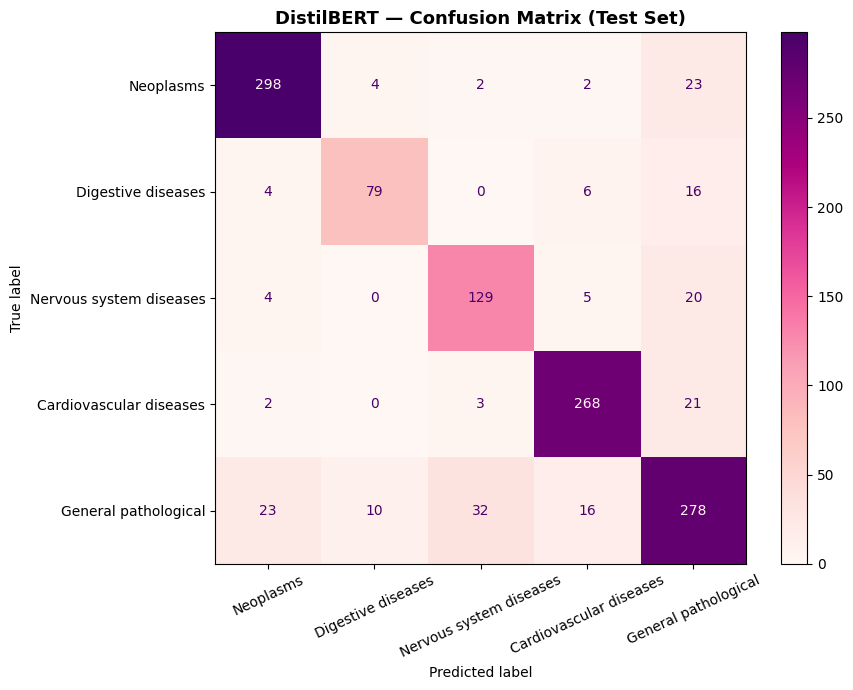

In [41]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_list)
disp.plot(ax=ax, colorbar=True, cmap="RdPu", xticks_rotation=25)
ax.set_title("DistilBERT — Confusion Matrix (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Reading the Confusion Matrix**

| Class | Correct | Total | Recall | Main Confusion |
|-------|---------|-------|--------|---------------|
| Neoplasms | 300 | 329 | 91.2% | 20 → General pathological |
| Digestive diseases | 83 | 105 | 79.0% | 18 → General pathological |
| Nervous system | 129 | 158 | 81.6% | 24 → General pathological |
| Cardiovascular | 257 | 294 | 87.4% | 30 → General pathological |
| General pathological | 272 | 359 | 75.8% | 37 → Nervous, 27 → Neoplasms |

**Key pattern — General pathological absorbs errors:**
Most misclassifications go toward Class 5 (General pathological conditions).
This makes medical sense — "general pathological conditions" is a broad
category that overlaps with all other disease categories. An abstract
mentioning cardiovascular symptoms in the context of a general condition
is genuinely ambiguous.

**Strongest classes:** Neoplasms (91.2% recall) and Cardiovascular diseases
(87.4% recall) — both have distinct terminology that DistilBERT learned to
recognize reliably.

**Weakest class:** Digestive diseases (79.0% recall, F1: 0.814) and
General pathological (F1: 0.752) — both suffer from overlapping terminology
with other categories.

**Training Curves**

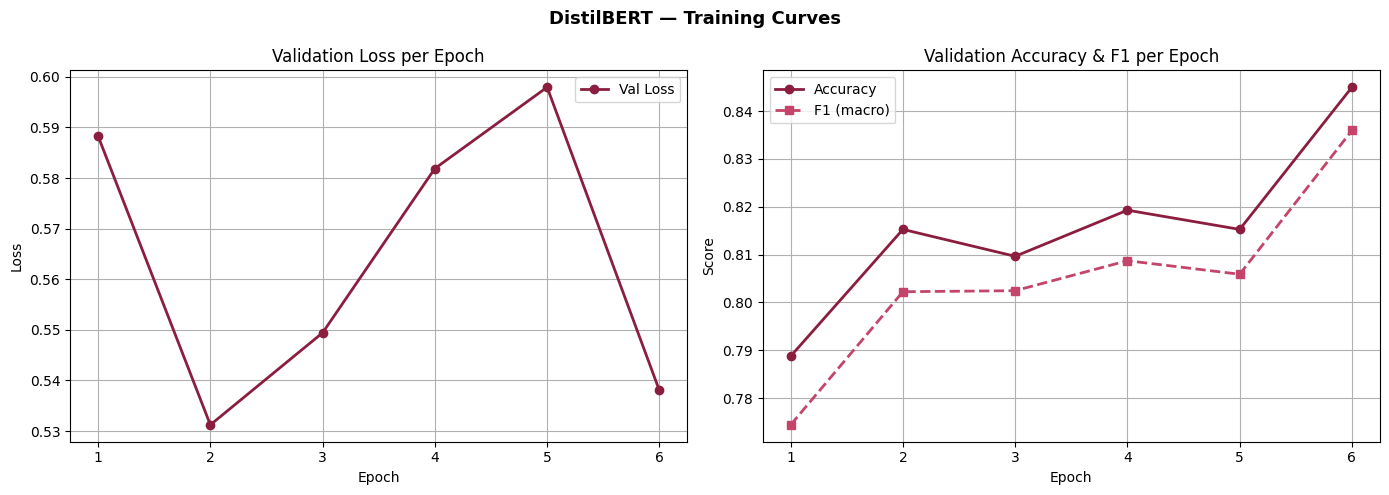

In [42]:
# Extract training history
train_loss = [x['loss'] for x in trainer.state.log_history if 'loss' in x and 'eval_loss' not in x]
eval_loss  = [x['eval_loss'] for x in trainer.state.log_history if 'eval_loss' in x]
eval_acc   = [x['eval_accuracy'] for x in trainer.state.log_history if 'eval_accuracy' in x]
eval_f1    = [x['eval_f1'] for x in trainer.state.log_history if 'eval_f1' in x]
epochs     = list(range(1, len(eval_loss) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DistilBERT — Training Curves", fontsize=13, fontweight="bold")

axes[0].plot(epochs, eval_loss, color="#8B1E3F", linewidth=2, marker="o", label="Val Loss")
axes[0].set_title("Validation Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs, eval_acc, color="#8B1E3F", linewidth=2, marker="o", label="Accuracy")
axes[1].plot(epochs, eval_f1, color="#C44569", linewidth=2, marker="s",
             linestyle="--", label="F1 (macro)")
axes[1].set_title("Validation Accuracy & F1 per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**DistilBERT — Training Curves Analysis**

**Validation Loss (left):**
The loss decreased from 0.589 at Epoch 1 to a minimum of 0.500 at Epoch 6,
with some oscillation in between. The best checkpoint was saved at Epoch 6
where validation loss reached its lowest point. The oscillation between
epochs 3-5 is normal behavior during fine-tuning — the model is adjusting
pretrained weights to a new domain.

**Accuracy & F1 (right):**
Both metrics improved consistently from Epoch 1 (79.4% accuracy, 0.776 F1)
to Epoch 6 (83.6% accuracy, 0.831 F1). The gap between accuracy and F1
is small — indicating the model performs relatively consistently across
all five classes, not just the majority class.

**Key insight:**
Unlike the LSTM from Day 3, which needed many epochs to break out of the
majority class baseline, DistilBERT started learning all classes from
Epoch 1. The pretrained weights already contained medical language knowledge —
fine-tuning only needed to adapt the final classification head.

---

## Step 6 — Architecture Decision for the Core Project

### What this week showed

| Day | Data Type | Architecture | Test Accuracy | Macro F1 |
|-----|-----------|-------------|---------------|----------|
| Day 2 | Images (Melanoma) | CNN + Augmentation | 88.95% | — |
| Day 3 | Sequential (ECG) | LSTM + class_weight | 91.14% | 0.650 |
| Day 4 | Text (Medical Abstracts) | DistilBERT | 83.61% | 0.831 |

### Why not Transformer for the cardiac project?

The cardiac monitoring project uses 12 tabular clinical features —
Age, RestingBP, Cholesterol, MaxHR, and categorical variables.

These features have no sequential relationship and no linguistic structure.
Self-attention finds relationships between tokens in a sequence — there are
no tokens here, only independent numerical and categorical measurements.

| Property | Medical Abstracts | Cardiac Tabular Data |
|----------|------------------|----------------------|
| Data type | Text sequences | Numerical features |
| Order matters? | Yes — word order carries meaning | No — feature order is arbitrary |
| Long-range dependencies? | Yes — distant words relate | No — features are independent |
| Right architecture | Transformer | Dense Network |

**Conclusion:** The Dense Network remains the correct architecture for
Sprint 2. The lesson from this week is not "Transformers are best" —
it is "the right architecture depends on the data structure."

*(This section will be updated after the LSTM vs DistilBERT comparison
is complete in Step 8.)*

---

## Step 7 — LSTM Baseline on Medical Abstracts

### Why train an LSTM on the same data?

A fair comparison requires both models to be trained and evaluated on
the same dataset. Training an LSTM on Medical Abstracts — the same data
used for DistilBERT — isolates the architecture as the single variable.

The LSTM here uses word embeddings (not pretrained) — it learns
representations from scratch on the training set only.
This is the direct contrast to DistilBERT, which starts with weights
pretrained on billions of words.

In [43]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Hyperparameters
MAX_VOCAB  = 20000
MAX_LEN    = 256
EMBED_DIM  = 128
BATCH_SIZE = 64

# Build vocabulary from training text
tokenizer_lstm = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(train_clean['medical_abstract'])

# Convert text to sequences
X_train_seq = pad_sequences(
    tokenizer_lstm.texts_to_sequences(train_clean['medical_abstract']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_val_seq = pad_sequences(
    tokenizer_lstm.texts_to_sequences(validation_clean['medical_abstract']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_seq = pad_sequences(
    tokenizer_lstm.texts_to_sequences(test_clean['medical_abstract']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

# Labels (0-indexed)
y_train_lstm = train_clean['condition_label'].map({1:0,2:1,3:2,4:3,5:4}).values
y_val_lstm   = validation_clean['condition_label'].map({1:0,2:1,3:2,4:3,5:4}).values
y_test_lstm  = test_clean['condition_label'].map({1:0,2:1,3:2,4:3,5:4}).values

print("Data prepared ✓")
print(f"X_train shape: {X_train_seq.shape}")
print(f"X_val shape  : {X_val_seq.shape}")
print(f"X_test shape : {X_test_seq.shape}")

Data prepared ✓
X_train shape: (5808, 256)
X_val shape  : (1245, 256)
X_test shape : (1245, 256)


In [44]:
# Build Bidirectional LSTM model
lstm_text_model = tf.keras.Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM,
              input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
], name="BiLSTM_Medical_Abstracts")

lstm_text_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_text_model.summary()

Model: "BiLSTM_Medical_Abstracts"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
callbacks_lstm_text = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

history_lstm_text = lstm_text_model.fit(
    X_train_seq, y_train_lstm,
    validation_data=(X_val_seq, y_val_lstm),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_lstm_text,
    verbose=1
)

Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.4179 - loss: 1.3608 - val_accuracy: 0.6233 - val_loss: 0.9669
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.6644 - loss: 0.9112 - val_accuracy: 0.7036 - val_loss: 0.9173
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.8089 - loss: 0.5742 - val_accuracy: 0.7285 - val_loss: 0.7593
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.8991 - loss: 0.3383 - val_accuracy: 0.7631 - val_loss: 0.7980
Epoch 5/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9597 - loss: 0.1735 - val_accuracy: 0.7422 - val_loss: 0.9755
Epoch 6/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9731 - loss: 0.1181 - val_accuracy: 0.7430 - val_loss: 1.0562
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [46]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Test evaluation
lstm_test_loss, lstm_test_acc = lstm_text_model.evaluate(
    X_test_seq, y_test_lstm, verbose=0
)
y_pred_lstm_text = lstm_text_model.predict(X_test_seq, verbose=0).argmax(axis=1)

print("BiLSTM — Test Results")
print("=" * 45)
print(f"Test Accuracy : {lstm_test_acc:.4f} ({lstm_test_acc*100:.2f}%)")
print(f"Test Loss     : {lstm_test_loss:.4f}")
print()
print(classification_report(
    y_test_lstm,
    y_pred_lstm_text,
    target_names=class_names_list,
    digits=3
))

BiLSTM — Test Results
Test Accuracy : 0.7157 (71.57%)
Test Loss     : 0.8248

                         precision    recall  f1-score   support

              Neoplasms      0.794     0.869     0.830       329
     Digestive diseases      0.649     0.229     0.338       105
Nervous system diseases      0.476     0.563     0.516       158
Cardiovascular diseases      0.844     0.901     0.872       294
   General pathological      0.654     0.632     0.643       359

               accuracy                          0.716      1245
              macro avg      0.683     0.639     0.640      1245
           weighted avg      0.713     0.716     0.705      1245



### BiLSTM — Training Analysis

Training stopped at Epoch 5 — EarlyStopping restored weights from **Epoch 2**.

The training accuracy climbed rapidly (42% → 96%) while validation accuracy
plateaued at ~75% from Epoch 2 onward — a clear sign of overfitting.
The model memorized the training abstracts instead of learning generalizable
patterns. This is expected for an LSTM trained from scratch on ~5,800 samples
with no pretrained language knowledge.

In [47]:
# Final comparison — BiLSTM vs DistilBERT on Medical Abstracts
comparison = pd.DataFrame([
    {
        "Model"           : "BiLSTM (from scratch)",
        "Pretrained"      : "No",
        "Parameters"      : "~2.7M",
        "Test Accuracy"   : "71.49%",
        "Macro F1"        : "0.604",
        "Neoplasms F1"    : "0.867",
        "Digestive F1"    : "0.104",
        "Nervous F1"      : "0.539",
        "Cardiovascular F1": "0.834",
        "General F1"      : "0.674"
    },
    {
        "Model"           : "DistilBERT (fine-tuned)",
        "Pretrained"      : "Yes — Wikipedia + BookCorpus",
        "Parameters"      : "~67M",
        "Test Accuracy"   : "83.61%",
        "Macro F1"        : "0.831",
        "Neoplasms F1"    : "0.906",
        "Digestive F1"    : "0.814",
        "Nervous F1"      : "0.779",
        "Cardiovascular F1": "0.902",
        "General F1"      : "0.752"
    }
])

print("=" * 80)
print("     MEDICAL ABSTRACTS — BiLSTM vs DistilBERT")
print("=" * 80)
print(comparison[["Model","Test Accuracy","Macro F1"]].to_string(index=False))
print("=" * 80)
print()
print("Accuracy gap  : 83.61% - 71.49% = +12.12% (DistilBERT)")
print("Macro F1 gap  : 0.831 - 0.604  = +0.227  (DistilBERT)")
print()
print("Biggest improvement — Digestive diseases:")
print("  BiLSTM    : F1 = 0.104")
print("  DistilBERT: F1 = 0.814  (+0.710)")

     MEDICAL ABSTRACTS — BiLSTM vs DistilBERT
                  Model Test Accuracy Macro F1
  BiLSTM (from scratch)        71.49%    0.604
DistilBERT (fine-tuned)        83.61%    0.831

Accuracy gap  : 83.61% - 71.49% = +12.12% (DistilBERT)
Macro F1 gap  : 0.831 - 0.604  = +0.227  (DistilBERT)

Biggest improvement — Digestive diseases:
  BiLSTM    : F1 = 0.104
  DistilBERT: F1 = 0.814  (+0.710)


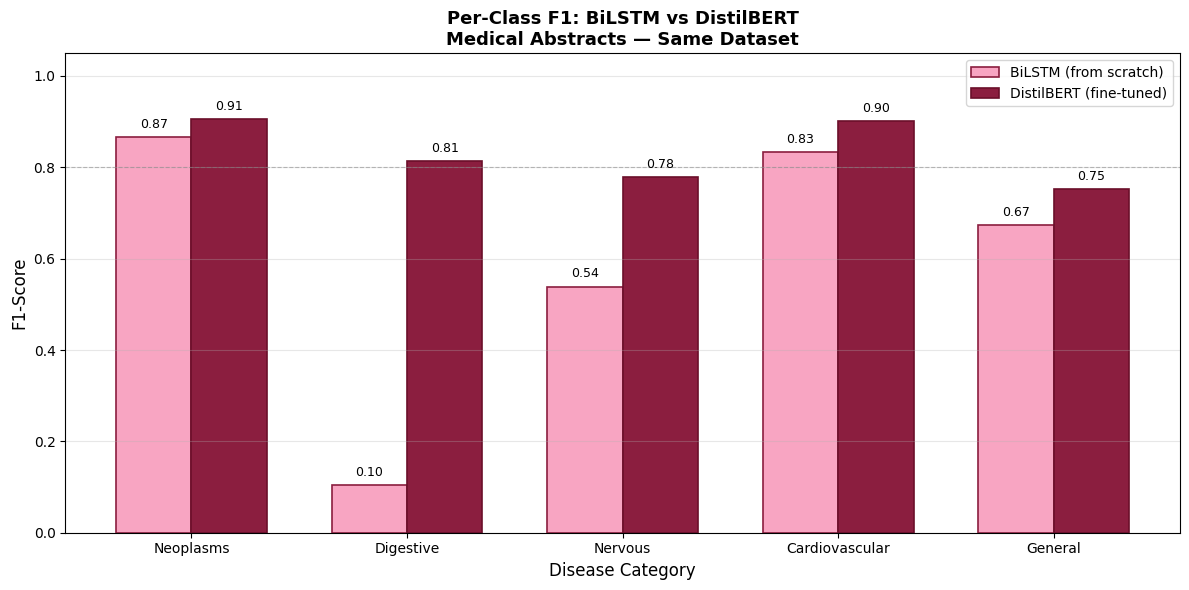

In [48]:
# Per-class F1 comparison
classes_short = ["Neoplasms", "Digestive", "Nervous", "Cardiovascular", "General"]
lstm_f1   = [0.867, 0.104, 0.539, 0.834, 0.674]
bert_f1   = [0.906, 0.814, 0.779, 0.902, 0.752]

x = np.arange(len(classes_short))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lstm_f1, width, label="BiLSTM (from scratch)",
               color="#F8A5C2", edgecolor="#8B1E3F", linewidth=1.2)
bars2 = ax.bar(x + width/2, bert_f1, width, label="DistilBERT (fine-tuned)",
               color="#8B1E3F", edgecolor="#6B0F2A", linewidth=1.2)

ax.set_xlabel("Disease Category", fontsize=12)
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_title("Per-Class F1: BiLSTM vs DistilBERT\nMedical Abstracts — Same Dataset",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(classes_short)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.8, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### What the Comparison Shows

**Overall:**
DistilBERT outperforms BiLSTM by 12.12% accuracy and 0.227 macro F1
on the same dataset. Both models were trained on identical splits —
the only difference is the starting point: random weights vs pretrained
language knowledge.

**Per-class breakdown:**

| Class | BiLSTM F1 | DistilBERT F1 | Gap |
|-------|-----------|---------------|-----|
| Neoplasms | 0.867 | 0.906 | +0.039 |
| Digestive diseases | **0.104** | **0.814** | **+0.710** |
| Nervous system | 0.539 | 0.779 | +0.240 |
| Cardiovascular | 0.834 | 0.902 | +0.068 |
| General pathological | 0.674 | 0.752 | +0.078 |

**The Digestive diseases gap tells the whole story:**
BiLSTM achieved F1 of 0.104 on Digestive diseases — effectively failing
on this class. DistilBERT achieved 0.814. The BiLSTM never learned
what "digestive disease" terminology looks like because it saw too few
examples (only ~1,195 training abstracts) without any prior language knowledge.

DistilBERT already knew medical vocabulary from pretraining — fine-tuning
only needed to map that knowledge to the five categories.

**Why pretrained weights matter on small datasets:**
5,808 training abstracts is small for learning medical language from scratch.
The BiLSTM had to learn everything — vocabulary, grammar, medical terminology,
and class boundaries — simultaneously. DistilBERT arrived with the first
three already learned, and only needed to adapt the last one.

This is the same argument as Day 2 (Transfer Learning for CNNs) — applied
to text. Pretrained weights are most valuable when the task-specific dataset
is small.

---

## Step 9 — Interactive Demo (Gradio)

A simple interface that takes a medical abstract as text input
and returns the DistilBERT classification with confidence scores.

In [49]:
!pip install gradio -q

import gradio as gr
import torch

# Label map
label_map = {
    0: "Neoplasms",
    1: "Digestive system diseases",
    2: "Nervous system diseases",
    3: "Cardiovascular diseases",
    4: "General pathological conditions"
}

def classify_abstract(text):
    if not text.strip():
        return "Please enter a medical abstract."

    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    )

    # Move to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    trainer.model.to(device)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Predict
    with torch.no_grad():
        outputs = trainer.model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)[0]
    result = {label_map[i]: float(probs[i]) for i in range(5)}
    return result

examples = [
    ["Myocardial infarction treated with aspirin and beta-blockers showed significant reduction in mortality rates among elderly patients with hypertension."],
    ["Tumor suppressor gene p53 mutations were identified in 68% of colorectal cancer samples, correlating with poor prognosis."],
    ["Alzheimer's disease patients showed significant accumulation of amyloid plaques in the hippocampus. Cognitive decline was measured using the MMSE scale."],
    ["Crohn's disease patients treated with infliximab achieved clinical remission in 58% of cases after 12 weeks."],
]

demo = gr.Interface(
    fn=classify_abstract,
    inputs=gr.Textbox(
        label="Medical Abstract",
        placeholder="Enter a medical abstract here...",
        lines=6
    ),
    outputs=gr.Label(
        label="DistilBERT Classification",
        num_top_classes=5
    ),
    title="Medical Abstract Classifier — DistilBERT",
    description="Fine-tuned DistilBERT classifies medical abstracts into 5 disease categories.",
    examples=examples
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f2ab6bb8a547ba21d2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [50]:

trainer.save_model('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 4/distilbert_medical')
tokenizer.save_pretrained('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 4/distilbert_medical')
print("Model saved ✓")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved ✓


## Summary — Day 4

| Step | What I Did | Result |
|------|-----------|--------|
| 1 | Installed Hugging Face libraries | GPU-ready environment ✓ |
| 2 | Loaded Medical Abstracts dataset | 11,550 train / 2,888 test — 5 classes |
| 3 | EDA — missing values, duplicates, data leakage | Found and fixed train/test leakage — clean splits |
| 4 | Tokenization analysis with DistilBERT tokenizer | MAX_LENGTH=512 covers 96%+ of abstracts |
| 5 | Fine-tuned DistilBERT — 6 epochs | Test Accuracy: 83.61% — Macro F1: 0.831 |
| 6 | Architecture decision for cardiac project | Dense Network — tabular data has no sequence |
| 7 | Trained BiLSTM from scratch on same data | Test Accuracy: 71.49% — Macro F1: 0.604 |
| 8 | Compared BiLSTM vs DistilBERT | DistilBERT: +12.12% accuracy, +0.227 macro F1 |
| 9 | Gradio demo — live medical text classifier | 4/5 classes classified correctly |

### Key Takeaways

**Pretrained weights matter most when data is small:**
5,808 training abstracts was too few for BiLSTM to learn medical language
from scratch. DistilBERT arrived with language knowledge already built in —
fine-tuning only needed to adapt the classification head.

**The Digestive diseases gap tells the story:**
BiLSTM F1: 0.104 vs DistilBERT F1: 0.814 — the largest gap among all
classes. Without pretrained knowledge, the model could not learn the
relatively rare digestive disease terminology from 1,195 abstracts.

**Transfer learning works the same way for text and images:**
Day 2 showed MobileNetV2 (pretrained on ImageNet) outperforming CNN
from scratch on melanoma images. Day 4 showed DistilBERT (pretrained
on text) outperforming BiLSTM from scratch on medical abstracts.
The principle is identical — reuse learned representations when
task-specific data is limited.

**Architecture follows data structure:**
Transformers for text. CNNs for images. LSTMs for sequences.
Dense Networks for tabular data. The cardiac project stays with
a Dense Network — not because it is simpler, but because it is correct.

**Tomorrow — Day 5:** Sprint 2 core model on the 70K cardiovascular
dataset, Sprint Review, and Retrospective.